In [2]:
import json

with open("../data/AlbaniaSAT/raw/Broad-leaved_Forest.geojson") as f:
    data = json.load(f)

print("Number of features:", len(data["features"]))
print("Property keys:", list(data["features"][0]["properties"].keys()))

Number of features: 500
Property keys: ['B2', 'B3', 'B4', 'B8', 'landcover']


In [3]:
import numpy as np

first = data["features"][0]["properties"]
b4 = first["B4"]

print("Type of B4:", type(b4))
print("Value of B4:", str(b4)[:200])

Type of B4: <class 'list'>
Value of B4: [[207.0, 208.0, 203.0, 208.0, 208.0, 201.0, 228.0, 228.0, 263.0, 413.0, 380.0, 380.0, 357.0, 415.0, 580.0, 580.0, 633.0, 548.0, 489.0, 489.0, 370.0, 387.0, 352.0, 352.0, 367.0, 346.0, 223.0, 223.0, 31


In [4]:
b4_array = np.array(first["B4"])
print("Shape:", b4_array.shape)

Shape: (65, 65)


In [5]:
import json
import numpy as np
import os

RAW_PATH = "../data/AlbaniaSAT/raw"
OUTPUT_PATH = "../data/AlbaniaSAT/processed"
os.makedirs(OUTPUT_PATH, exist_ok=True)

BANDS = ["B4", "B3", "B2", "B8"]

class_names = [
    "Broad-leaved_Forest",
    "Coniferous_Forest", 
    "Shrubland",
    "Agricultural",
    "Grassland",
    "Olive_Groves",
    "Urban",
    "Water"
]

all_patches = []
all_labels = []

for label_idx, class_name in enumerate(class_names):
    filepath = os.path.join(RAW_PATH, f"{class_name}.geojson")
    
    with open(filepath) as f:
        data = json.load(f)
    
    patches = []
    for feature in data["features"]:
        props = feature["properties"]
        # Stack bands into (4, 64, 64) array
        bands = np.array([props[b] for b in BANDS], dtype=np.float32)
        bands = bands[:, :64, :64]  # crop to 64x64
        patches.append(bands)
    
    patches = np.array(patches)
    labels = np.full(len(patches), label_idx, dtype=np.int64)
    
    all_patches.append(patches)
    all_labels.append(labels)
    print(f"{class_name}: {len(patches)} patches, shape {patches[0].shape}")

# Stack everything
X = np.concatenate(all_patches, axis=0)
y = np.concatenate(all_labels, axis=0)

print(f"\nFinal dataset: {X.shape} patches, {y.shape} labels")

# Save
np.save(os.path.join(OUTPUT_PATH, "patches.npy"), X)
np.save(os.path.join(OUTPUT_PATH, "labels.npy"), y)
print("Saved to processed/")

Broad-leaved_Forest: 500 patches, shape (4, 64, 64)
Coniferous_Forest: 500 patches, shape (4, 64, 64)
Shrubland: 500 patches, shape (4, 64, 64)
Agricultural: 500 patches, shape (4, 64, 64)
Grassland: 500 patches, shape (4, 64, 64)
Olive_Groves: 500 patches, shape (4, 64, 64)
Urban: 500 patches, shape (4, 64, 64)
Water: 500 patches, shape (4, 64, 64)

Final dataset: (4000, 4, 64, 64) patches, (4000,) labels
Saved to processed/


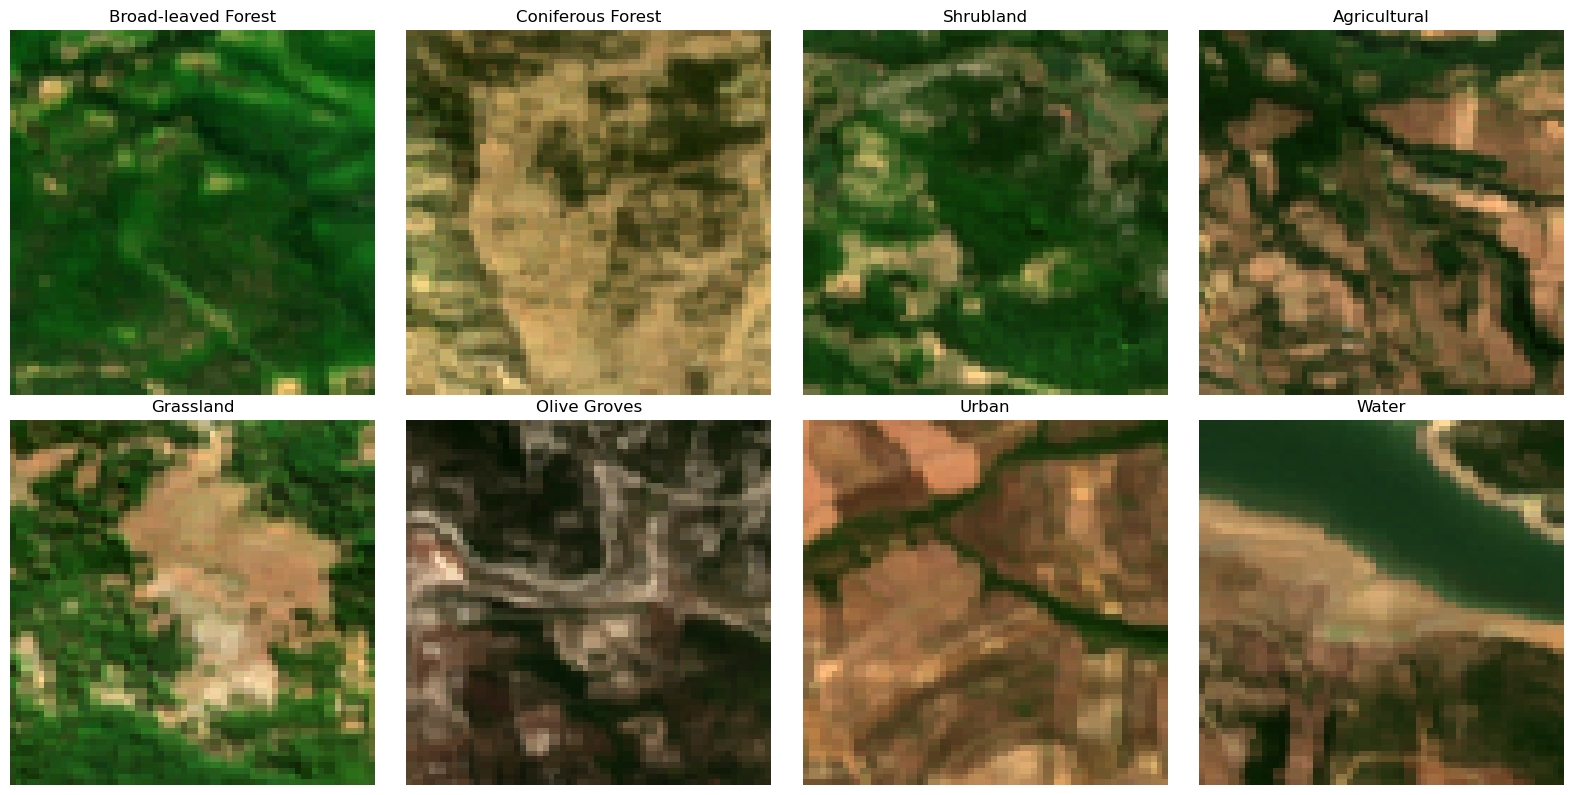

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
class_names_display = [c.replace("_", " ") for c in class_names]

for i, ax in enumerate(axes.flat):
    # RGB = B4, B3, B2 (indices 0, 1, 2)
    patch = X[i * 500][:3]  # one patch per class
    rgb = np.transpose(patch, (1, 2, 0))
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())  # normalize to 0-1
    ax.imshow(rgb)
    ax.set_title(class_names_display[i])
    ax.axis("off")

plt.tight_layout()
plt.savefig("../results/figures/sample_patches.png")
plt.show()

In [7]:
from PIL import Image
import os
import numpy as np

OUTPUT_IMG_PATH = "../data/AlbaniaSAT/images"

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(OUTPUT_IMG_PATH, class_name)
    os.makedirs(class_dir, exist_ok=True)
    
    # Get all patches for this class
    class_patches = X[i * 500:(i + 1) * 500]
    
    for j, patch in enumerate(class_patches):
        # RGB = B4, B3, B2
        rgb = patch[:3]
        rgb = np.transpose(rgb, (1, 2, 0))
        
        # Normalize to 0-255
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        rgb = (rgb * 255).astype(np.uint8)
        
        img = Image.fromarray(rgb)
        img.save(os.path.join(class_dir, f"{class_name}_{j:05d}.jpg"))
    
    print(f"Saved {len(class_patches)} images for {class_name}")

print("Done! All images saved.")

Saved 500 images for Broad-leaved_Forest
Saved 500 images for Coniferous_Forest
Saved 500 images for Shrubland
Saved 500 images for Agricultural
Saved 500 images for Grassland
Saved 500 images for Olive_Groves
Saved 500 images for Urban
Saved 500 images for Water
Done! All images saved.


In [9]:
from PIL import Image
import os
import numpy as np

OUTPUT_IMG_PATH = "../data/AlbaniaSAT/images_v2"

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(OUTPUT_IMG_PATH, class_name)
    os.makedirs(class_dir, exist_ok=True)
    
    # Get patches for this class using label index
    class_indices = np.where(y == i)[0]
    class_patches = X[class_indices]
    
    for j, patch in enumerate(class_patches):
        rgb = patch[:3]
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        rgb = (rgb * 255).astype(np.uint8)
        
        img = Image.fromarray(rgb)
        img.save(os.path.join(class_dir, f"{class_name}_{j:05d}.jpg"))
    
    print(f"Saved {len(class_patches)} images for {class_name}")

print("Done!")

Saved 500 images for Broad-leaved_Forest
Saved 500 images for Coniferous_Forest
Saved 500 images for Shrubland
Saved 500 images for Agricultural
Saved 500 images for Grassland
Saved 500 images for Olive_Groves
Saved 500 images for Urban
Saved 500 images for Water
Done!


In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y, return_counts=True))

X shape: (4000, 4, 64, 64)
y shape: (4000,)
Unique labels: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([500, 500, 500, 500, 500, 500, 500, 500]))


In [11]:
import os
print(os.path.exists("../data/AlbaniaSAT/processed_v2/patches.npy"))
print(os.path.exists("../data/AlbaniaSAT/processed/patches.npy"))

True
True


In [12]:
X = np.load("../data/AlbaniaSAT/processed_v2/patches.npy")
y = np.load("../data/AlbaniaSAT/processed_v2/labels.npy")

print("X shape:", X.shape)
print("Unique labels:", np.unique(y, return_counts=True))

X shape: (8000, 4, 64, 64)
Unique labels: (array([0, 1, 2, 3, 4, 5, 6, 7]), array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]))


In [13]:
from PIL import Image
import os
import numpy as np

OUTPUT_IMG_PATH = "../data/AlbaniaSAT/images_v2"

for i, class_name in enumerate(class_names):
    class_dir = os.path.join(OUTPUT_IMG_PATH, class_name)
    os.makedirs(class_dir, exist_ok=True)
    
    class_indices = np.where(y == i)[0]
    class_patches = X[class_indices]
    
    for j, patch in enumerate(class_patches):
        rgb = patch[:3]
        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        rgb = (rgb * 255).astype(np.uint8)
        
        img = Image.fromarray(rgb)
        img.save(os.path.join(class_dir, f"{class_name}_{j:05d}.jpg"))
    
    print(f"Saved {len(class_patches)} images for {class_name}")

print("Done!")

Saved 1000 images for Broad-leaved_Forest
Saved 1000 images for Coniferous_Forest
Saved 1000 images for Shrubland
Saved 1000 images for Agricultural
Saved 1000 images for Grassland
Saved 1000 images for Olive_Groves
Saved 1000 images for Urban
Saved 1000 images for Water
Done!
